In [61]:
import matplotlib as mpl
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd 
import random 
from torchvision.models import resnet50, ResNet50_Weights
from ignite.contrib.metrics.regression import MeanAbsoluteRelativeError

from torch.utils.data import Dataset, DataLoader
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch import nn
import torch.nn.functional as F

from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from os import listdir
from os.path import isfile, join
import pandas as pd
import os
import numpy as np
import umap
from sklearn.datasets import fetch_openml
import seaborn as sns
from sklearn import preprocessing
from sklearn import cluster
from sklearn import manifold
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import itertools

In [62]:
#Getting the images:
unique_path = r"../data\grand_scraper_folder\unique_scrandle_pictures_FULL.csv"
unique_dataframe = pd.read_csv(unique_path)
unique_entries = [unique_dataframe["occurrences"][i].split("|")[0].split(" ")[0] + ".webp" for i in range(len(unique_dataframe["occurrences"]))]

#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
image_Data_low_res = []




#Folder with folders of images:
base_folder = r"../data\scrandle_padded_low_res_data"

current_folder = None


#Looping over all dates in the listed directory/folder:
for entry in sorted(unique_entries):
    date, image_placement = entry.split(":")
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    print(f"Processing {entry}")
    
    #Reading entry image:
    image_path = os.path.join(date_path, image_placement)
    image_Data_low_res.append({
                    "date": date,
                    "image_name": image_placement,
                    "RGB": plt.imread(image_path, format="webp"),
                })

Processing 2025-04-20:0_left.webp
Processing 2025-04-20:0_right.webp
Processing 2025-04-20:1_left.webp
Processing 2025-04-20:1_right.webp
Processing 2025-04-20:2_left.webp
Processing 2025-04-20:2_right.webp
Processing 2025-04-20:3_left.webp
Processing 2025-04-20:3_right.webp
Processing 2025-04-20:4_left.webp
Processing 2025-04-20:4_right.webp
Processing 2025-04-20:5_left.webp
Processing 2025-04-20:5_right.webp
Processing 2025-04-20:6_left.webp
Processing 2025-04-20:6_right.webp
Processing 2025-04-20:7_left.webp
Processing 2025-04-20:7_right.webp
Processing 2025-04-20:8_left.webp
Processing 2025-04-20:8_right.webp
Processing 2025-04-20:9_left.webp
Processing 2025-04-20:9_right.webp
Processing 2025-04-21:0_left.webp
Processing 2025-04-21:0_right.webp
Processing 2025-04-21:1_left.webp
Processing 2025-04-21:1_right.webp
Processing 2025-04-21:2_left.webp
Processing 2025-04-21:2_right.webp
Processing 2025-04-21:3_left.webp
Processing 2025-04-21:3_right.webp
Processing 2025-04-21:4_left.webp


In [529]:
#Settings:{'batch_size': 36, 'latent_dim': 91}
training_samples = 2500
batch_size = 36#110#22
latent_d = 91#110#88

In [530]:
#Getting only the images:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device: {device}")
image_only_low_res = []
for i in range(len(image_Data_low_res)):
    image_only_low_res.append(image_Data_low_res[i]["RGB"])

image_train = torch.from_numpy(np.array(image_only_low_res[:training_samples])/255).permute(0,3,1,2).float().to(device)
image_test = torch.from_numpy(np.array(image_only_low_res[training_samples:])/255).permute(0,3,1,2).float().to(device)

Using Device: cuda


In [531]:
#Next, for the dataloader:
class ImageDataset(Dataset):
    def __init__(self, images):
        
        self.images = images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]

        return image

dataset_train = ImageDataset(image_train)
dataset_test = ImageDataset(image_test)
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=True)

### Model(Adapted from Troels autoencoder example solution)

In [532]:
class Encoder(nn.Module):
    
    def __init__(self, encoded_space_dim):
        super().__init__()
        
        ### Convolutional section:
        # So we decide to take our 1 input image and first apply 8 kernels/filters of size 3x3
        # with a stride (i.e. step size) of 2 and padding the edge with one layer.
        # This output goes through a ReLU and then through 16 new kernels/filters
        # of the same size, stride and padding, which is then BatchNorm'ed, ReLU'ed, and finally
        # convoluted a third time, again doubling the number of kernels/filters (quite standard!).
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=0),
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True)
        )
        
        ### Flatten layer
        # The images/matrices are then flatten'ed (put into one long array), put through a linear layer,
        # then a ReLU, and then finally another linear layer, which boils it down to the latent space
        # dimension.
        self.flatten = nn.Flatten(start_dim=1)
        ### Linear section
        self.encoder_lin = nn.Sequential(
            nn.Linear(11*9*32, 128),
            nn.ReLU(True),
            nn.Linear(128, encoded_space_dim)
        )
        
    def forward(self, x):
        x = self.encoder_cnn(x)
        x = self.flatten(x)
        x = self.encoder_lin(x)
        return x
    
class Decoder(nn.Module):
    
    def __init__(self, encoded_space_dim):
        super().__init__()
        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 11*9*32),
            nn.ReLU(True)
        )

        ### The decoder does the exact opposite, reconstructing the images from the latent space values.
        self.unflatten = nn.Unflatten(dim=1, 
        unflattened_size=(32, 11, 9))

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=(1,1)),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=0, output_padding=(0,1)),
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 3, 3, stride=2, padding=0, output_padding=(1,0))
        )
        
    def forward(self, x):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        x = torch.sigmoid(x)
        return x

In [533]:
# Define loss function and training parameters:
# Define the loss function
loss_fn = nn.L1Loss()

# Define an optimizer (both for the encoder and the decoder!)
lr = 0.001

# Set the random seed for reproducible results
torch.manual_seed(42)

# Initialize the two networks
#NOTE: d was initially 4. d=30 works really well!
#NOTE further: There seems to be a sweet spot between 30 and 50.
#d = 30
encoder = Encoder(encoded_space_dim=latent_d).to(device)
decoder = Decoder(encoded_space_dim=latent_d).to(device)
params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
]

optimizer = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)

In [534]:
# Define training and validation functions:

### Training function
def train_epoch(encoder, decoder, dataloader, loss_fn, optimizer):
    # Set train mode for both the encoder and the decoder
    encoder.train()
    decoder.train()
    train_loss = []
    # Iterate the dataloader (we do not need the label values, this is unsupervised learning)
    for image_batch in dataloader: # with "_" we just ignore the labels (the second element of the dataloader tuple)
        # Encode data
        encoded_data = encoder(image_batch)
        # Decode data
        decoded_data = decoder(encoded_data)
        #test = decoded_data.detach().cpu()
        #break
        #Prining the decoded image:
        # Evaluate loss
        loss = loss_fn(decoded_data, image_batch)
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Print batch loss
#         print('\t partial train loss (single batch): %f' % (loss.data))
        train_loss.append(loss.detach().cpu().numpy())

    return np.mean(train_loss)
    #return test


### Testing function
def test_epoch(encoder, decoder, dataloader, loss_fn):
    # Set evaluation mode for encoder and decoder
    encoder.eval()
    decoder.eval()
    with torch.no_grad(): # No need to track the gradients
        # Define the lists to store the outputs for each batch
        conc_out = []
        conc_label = []
        for image_batch in dataloader:
            # Encode data
            encoded_data = encoder(image_batch)
            # Decode data
            decoded_data = decoder(encoded_data)
            # Append the network output and the original image to the lists
            conc_out.append(decoded_data.cpu())
            conc_label.append(image_batch.cpu())
        # Create a single tensor with all the values in the lists
        conc_out = torch.cat(conc_out)
        conc_label = torch.cat(conc_label) 
        # Evaluate global loss
        val_loss = loss_fn(conc_out, conc_label)
    return val_loss.data

In [535]:
diz_loss = {'train_loss':[],'val_loss':[]}
lrs = []

In [559]:
#code to change learning rate:
lr = 0.0001
params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
]
optimizer = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-05

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-05
)

In [560]:
# Train the model
torch.cuda.manual_seed(42)
#torch.use_deterministic_algorithms(True)

num_epochs = 50
for epoch in range(num_epochs):
    train_loss = train_epoch(encoder,decoder, loader_train, loss_fn, optimizer)
    val_loss = test_epoch(encoder,decoder,loader_test,loss_fn)
    print('\n EPOCH {}/{} \t train loss {} \t val loss {}'.format(epoch + 1, num_epochs,train_loss,val_loss))
    diz_loss['train_loss'].append(train_loss)
    diz_loss['val_loss'].append(val_loss)
    lrs.append(lr)


 EPOCH 1/50 	 train loss 0.08269766718149185 	 val loss 0.08368456363677979

 EPOCH 2/50 	 train loss 0.08213680237531662 	 val loss 0.08350598067045212

 EPOCH 3/50 	 train loss 0.08199939876794815 	 val loss 0.08358201384544373

 EPOCH 4/50 	 train loss 0.08183157444000244 	 val loss 0.08348525315523148

 EPOCH 5/50 	 train loss 0.0817817822098732 	 val loss 0.0835929811000824

 EPOCH 6/50 	 train loss 0.08163043111562729 	 val loss 0.08351011574268341

 EPOCH 7/50 	 train loss 0.0816740021109581 	 val loss 0.08359715342521667

 EPOCH 8/50 	 train loss 0.08140996098518372 	 val loss 0.08348389714956284

 EPOCH 9/50 	 train loss 0.08136913925409317 	 val loss 0.08375333994626999

 EPOCH 10/50 	 train loss 0.08146204799413681 	 val loss 0.08359411358833313

 EPOCH 11/50 	 train loss 0.08136969059705734 	 val loss 0.08368659764528275

 EPOCH 12/50 	 train loss 0.08120185136795044 	 val loss 0.08353331685066223

 EPOCH 13/50 	 train loss 0.08129746466875076 	 val loss 0.0838914662599563

KeyboardInterrupt: 

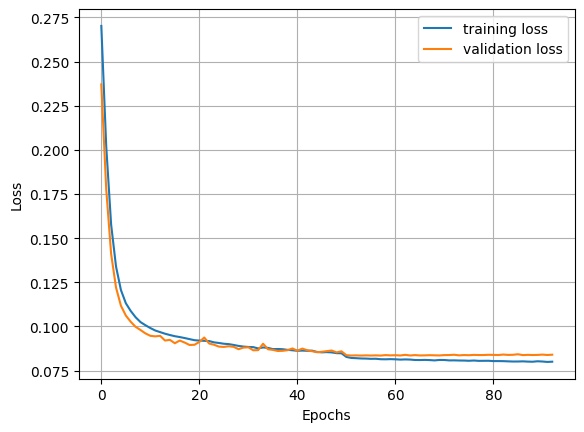

In [568]:
#Plotting loss:
plt.plot(diz_loss["train_loss"], label = "training loss")
plt.plot(diz_loss["val_loss"], label = "validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
#plt.xlim(40, 100)
#plt.ylim(0.08, 0.1)
plt.legend()
plt.grid()

In [563]:
encoder.eval()
decoder.eval()

Decoder(
  (decoder_lin): Sequential(
    (0): Linear(in_features=91, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=3168, bias=True)
    (3): ReLU(inplace=True)
  )
  (unflatten): Unflatten(dim=1, unflattened_size=(32, 11, 9))
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), output_padding=(0, 1))
    (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(8, 3, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 0))
  )
)

In [564]:
def check_encoder(image_id, train_test):
    reconstruct = decoder(encoder(train_test[image_id].unsqueeze(1).cpu().permute(1,0,2,3).to(device))).detach().cpu().numpy()[0].transpose(1,2,0)
    original = train_test[image_id].cpu().numpy().transpose(1,2,0)
    return reconstruct, original

Showing image comparison for image nr. 2433


<Figure size 1200x12000 with 0 Axes>

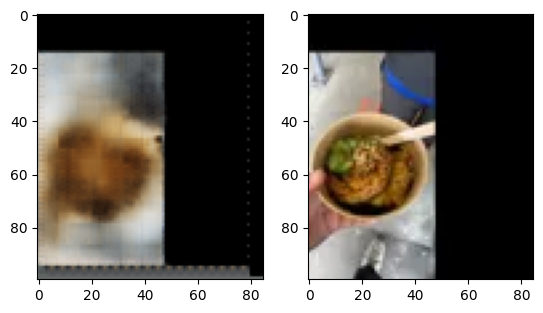

In [570]:
plt.figure(figsize=(12, 120))
random_num = np.random.randint(0, training_samples)
image_id = random_num#390
#NOTE: tried running with nearly all data as training data after sending image on discord!
#subplot(r,c) provide the no. of rows and columns
print("Showing image comparison for image nr.", random_num)
f, axarr = plt.subplots(1,2) 

# use the created array to output your multiple images. In this case I have stacked 4 images vertically
axarr[0].imshow(check_encoder(image_id, image_train)[0])
axarr[1].imshow(check_encoder(image_id, image_train)[1])



Showing image comparison for image nr. 455


<Figure size 1200x12000 with 0 Axes>

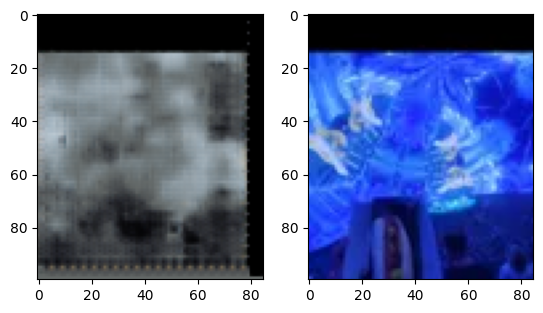

In [625]:
plt.figure(figsize=(12, 120))
random_num2 = np.random.randint(0, len(image_only_low_res[training_samples:]))
image_id = random_num2
print("Showing image comparison for image nr.", random_num2)
#NOTE: tried running with nearly all data as training data after sending image on discord!
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1,2) 

# use the created array to output your multiple images. In this case I have stacked 4 images vertically
axarr[0].imshow(check_encoder(image_id, image_test)[0])
axarr[1].imshow(check_encoder(image_id, image_test)[1])

### Optimizing some parameters using optuna:

In [528]:
import optuna
torch.backends.cudnn.deterministic = True

def objective(trial):
    batch_size = trial.suggest_int('batch_size', 20, 120)
    #weight_decay = trial.suggest_float("weight_decay", 0.00001, 0.0001)
    latent_dim = trial.suggest_int("latent_dim", 10, 150)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    image_train = torch.from_numpy(np.array(image_only_low_res[:training_samples])/255).permute(0,3,1,2).float().to(device)
    image_test = torch.from_numpy(np.array(image_only_low_res[training_samples:])/255).permute(0,3,1,2).float().to(device)

    class ImageDataset(Dataset):
        def __init__(self, images):
        
            self.images = images

        def __len__(self):
            return len(self.images)

        def __getitem__(self, idx):
            image = self.images[idx]

            return image

    dataset_train = ImageDataset(image_train)
    dataset_test = ImageDataset(image_test)
    loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    loader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=True)
    class Encoder(nn.Module):
    
        def __init__(self, encoded_space_dim):
            super().__init__()
        
        ### Convolutional section:
        # So we decide to take our 1 input image and first apply 8 kernels/filters of size 3x3
        # with a stride (i.e. step size) of 2 and padding the edge with one layer.
        # This output goes through a ReLU and then through 16 new kernels/filters
        # of the same size, stride and padding, which is then BatchNorm'ed, ReLU'ed, and finally
        # convoluted a third time, again doubling the number of kernels/filters (quite standard!).
            self.encoder_cnn = nn.Sequential(
                nn.Conv2d(3, 8, 3, stride=2, padding=0),
                nn.ReLU(True),
                nn.Conv2d(8, 16, 3, stride=2, padding=0),
                nn.BatchNorm2d(16),
                nn.ReLU(True),
                nn.Conv2d(16, 32, 3, stride=2, padding=0),
                nn.ReLU(True)
            )
        
        ### Flatten layer
        # The images/matrices are then flatten'ed (put into one long array), put through a linear layer,
        # then a ReLU, and then finally another linear layer, which boils it down to the latent space
        # dimension.
            self.flatten = nn.Flatten(start_dim=1)
        ### Linear section
            self.encoder_lin = nn.Sequential(
                nn.Linear(11*9*32, 128),
                nn.ReLU(True),
                nn.Linear(128, encoded_space_dim)
            )
        
        def forward(self, x):
            x = self.encoder_cnn(x)
            x = self.flatten(x)
            x = self.encoder_lin(x)
            return x
    
    class Decoder(nn.Module):
    
        def __init__(self, encoded_space_dim):
            super().__init__()
            self.decoder_lin = nn.Sequential(
                nn.Linear(encoded_space_dim, 128),
                nn.ReLU(True),
                nn.Linear(128, 11*9*32),
                nn.ReLU(True)
            )

        ### The decoder does the exact opposite, reconstructing the images from the latent space values.
            self.unflatten = nn.Unflatten(dim=1, 
            unflattened_size=(32, 11, 9))

            self.decoder_conv = nn.Sequential(
                nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=(1,1)),
                nn.BatchNorm2d(16),
                nn.ReLU(True),
                nn.ConvTranspose2d(16, 8, 3, stride=2, padding=0, output_padding=(0,1)),
                nn.BatchNorm2d(8),
                nn.ReLU(True),
                nn.ConvTranspose2d(8, 3, 3, stride=2, padding=0, output_padding=(1,0))
            )
        
        def forward(self, x):
            x = self.decoder_lin(x)
            x = self.unflatten(x)
            x = self.decoder_conv(x)
            x = torch.sigmoid(x)
            return x
        loss_fn = nn.L1Loss()

# Define an optimizer (both for the encoder and the decoder!)
    lr = 0.001

# Set the random seed for reproducible results
    torch.manual_seed(42)

# Initialize the two networks
#NOTE: d was initially 4. d=30 works really well!
#NOTE further: There seems to be a sweet spot between 30 and 50.
#d = 30

    optimizer = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)


    torch.manual_seed(42)
    random.seed(42)
    np.random.seed(42)
    lr = 0.001
    encoder_opt = Encoder(encoded_space_dim=latent_dim).to(device)
    decoder_opt = Decoder(encoded_space_dim=latent_dim).to(device)
    params_to_optimize_opt = [
    {'params': encoder_opt.parameters()},
    {'params': decoder_opt.parameters()}
    ]
    num_epochs = 50
    torch.cuda.manual_seed(42)
    optimizer_opt = torch.optim.Adam(params_to_optimize_opt, lr=lr, weight_decay=0.00001)
    for epoch in range(num_epochs):
        #if epoch == 0:
            #torch.cuda.manual_seed_all(42)
            #torch.use_deterministic_algorithms(True)
        train_loss = train_epoch(encoder_opt, decoder_opt, loader_train, loss_fn, optimizer_opt)
        val_loss = test_epoch(encoder_opt, decoder_opt, loader_test, loss_fn)

    return val_loss

study = optuna.create_study(study_name="autoencoder study", direction='minimize', sampler=torch.cuda.manual_seed(42))
study.optimize(objective, n_trials=150, show_progress_bar=True, n_jobs=1)


study.best_params

[I 2026-06-03 14:43:50,992] A new study created in memory with name: autoencoder study


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-06-03 14:44:06,815] Trial 0 finished with value: 0.08837322145700455 and parameters: {'batch_size': 67, 'latent_dim': 139}. Best is trial 0 with value: 0.08837322145700455.
[I 2026-06-03 14:44:33,689] Trial 1 finished with value: 0.10440503060817719 and parameters: {'batch_size': 33, 'latent_dim': 14}. Best is trial 0 with value: 0.08837322145700455.
[I 2026-06-03 14:45:08,082] Trial 2 finished with value: 0.0927538350224495 and parameters: {'batch_size': 32, 'latent_dim': 34}. Best is trial 0 with value: 0.08837322145700455.
[I 2026-06-03 14:45:36,006] Trial 3 finished with value: 0.1007215604186058 and parameters: {'batch_size': 52, 'latent_dim': 20}. Best is trial 0 with value: 0.08837322145700455.
[I 2026-06-03 14:45:49,699] Trial 4 finished with value: 0.10115138441324234 and parameters: {'batch_size': 117, 'latent_dim': 61}. Best is trial 0 with value: 0.08837322145700455.
[I 2026-06-03 14:46:38,824] Trial 5 finished with value: 0.09551053494215012 and parameters: {'batch

{'batch_size': 36, 'latent_dim': 91}

### Next, lets get all the loss values, and plot them:


In [644]:
#All images in torch tensors:
image_torch = torch.from_numpy(np.array(image_only_low_res[:])/255).permute(0,3,1,2).float().to(device)
image_loss = []
def check_encoder_torch(image_id, train_test):
    reconstruct = decoder(encoder(train_test[image_id].unsqueeze(1).cpu().permute(1,0,2,3).to(device))).detach().cpu()[0].permute(1,2,0)
    original = train_test[image_id].cpu().numpy().transpose(1,2,0)
    return reconstruct, original
for i in range(len(image_torch)):
    rec, orig = check_encoder_torch(i, image_torch)
    rec_cat = rec.flatten()
    orig_cat = orig.flatten()
    val_loss = loss_fn(rec_cat, orig_cat)
    image_loss.append(val_loss)





TypeError: 'int' object is not callable

In [647]:
rec, orig = check_encoder_torch(0, image_torch)


In [649]:
rec_test = rec.flatten()
orig_test = orig.flatten()
loss_fn(rec_test, orig_test)

TypeError: 'int' object is not callable

In [651]:
loss = nn.L1Loss()
input = torch.randn(3, 5, requires_grad=True)
target = torch.randn(3, 5)
output = loss(input, target)
output

tensor(0.9164, grad_fn=<MeanBackward0>)